# poseaudit demo: how far off is the elbow angle a pose model measures?

A good mAP does not tell you how far off the **angles, tilts and lengths** read off the keypoints are.
[`poseaudit`](https://github.com/8rulerstar/poseaudit) reads the measurement off the ground truth and off the prediction and reports the difference the way a measuring instrument is judged: how large, how often large, where, biased which way, and how sure you can be of each figure.

This notebook audits the left elbow angle (COCO keypoints 5, 7, 9) of `yolo11n-pose` against COCO's human labels on 200 val2017 images, then shows how to run it on your own data. It needs no GPU and runs in under a minute.

In [1]:
# numpy is the only dependency; Colab already has matplotlib for the plot
%pip install -q poseaudit
import poseaudit as pa

print("poseaudit", pa.__version__)

poseaudit 0.1.4


In [2]:
# The demo data: COCO annotations (keypoint fields only, CC BY 4.0) and yolo11n-pose results
import urllib.request

BASE = (
    "https://raw.githubusercontent.com/8rulerstar/poseaudit/main/examples/coco_elbow/"
)
for name in ["gt_200.json", "pred_yolo11n.json"]:
    urllib.request.urlretrieve(BASE + name, name)
    print("downloaded", name)

downloaded gt_200.json
downloaded pred_yolo11n.json


## 1. The command line

The same command as the README demo. `--angle 5,7,9` is the interior angle at the elbow (shoulder, elbow, wrist; indices count from 0), `--big-error 15` says what counts as a large error, `--size-bands 30,60` splits the readings by arm segment length in pixels.

In [3]:
!poseaudit audit --format coco --gt gt_200.json --pred pred_yolo11n.json \
    --angle 5,7,9 --big-error 15 --size-bands 30,60

angle (5, 7, 9): read 322 of 380 labelled instances
  not read     no matching prediction 35, prediction lacked a point 23, unmeasurable 0
  not counted  206 with a point unlabelled in the truth, 79 unmatched predictions
  bias         +2.27° [-1.21 to +6.15], median +0.52°
  limits       -50.90° to +79.99° (percentile, 2.5th to 97.5th; JSON percentile_limits)
  |error|      mean 19.48° [17.05 to 22.13], median 12.59°, 95th pct 68.99°
  RMSE         29.57° [25.30 to 33.94]
  >= 15°       43.2% [37.9% to 48.6%]
  by size      0-30 px 58% (n 134), 30-60 px 37% (n 112), 60+ px 26% (n 76)
  slope        0.731 [0.639 to 0.814] (pred on truth, 1 is ideal); Theil-Sen 0.786
  ICC(A,1)     0.762 [0.677 to 0.827]
  ! 2.5% of errors fall below the normal limits and 4.3% above them, against 2.5% each for a normal error: use the percentile limits.


## 2. The same in Python

The demo predictions store each point as seen (2) or not (0), so `min_confidence=0.5` changes nothing here; with your own results file it sets which points count as seen.

read 322 of 380 measurable instances
mean |error|  19.48 deg, 95% CI 17.05 to 22.13
bias          +2.27 deg
>= 15 deg     43.2%
slope         0.731 (jitter alone: 0.871, gap -0.140)
not read      NotRead(unlabelled=206, missed=35, no_predicted_point=23, unmeasurable=0, too_few_in_frame=0, unmatched_predictions=79)

arm 0 to 30 px: n 134, mean |error| 25.55 deg, >= 15 deg 58%
arm 30 to 60 px: n 112, mean |error| 16.57 deg, >= 15 deg 37%
arm 60+ px: n 76, mean |error| 13.06 deg, >= 15 deg 26%

largest errors:
  000000057672.jpg: truth 53.8, predicted 168.8, error +115.0
  000000057672.jpg: truth 52.2, predicted 164.1, error +111.9
  000000005001.jpg: truth 164.2, predicted 52.5, error -111.7


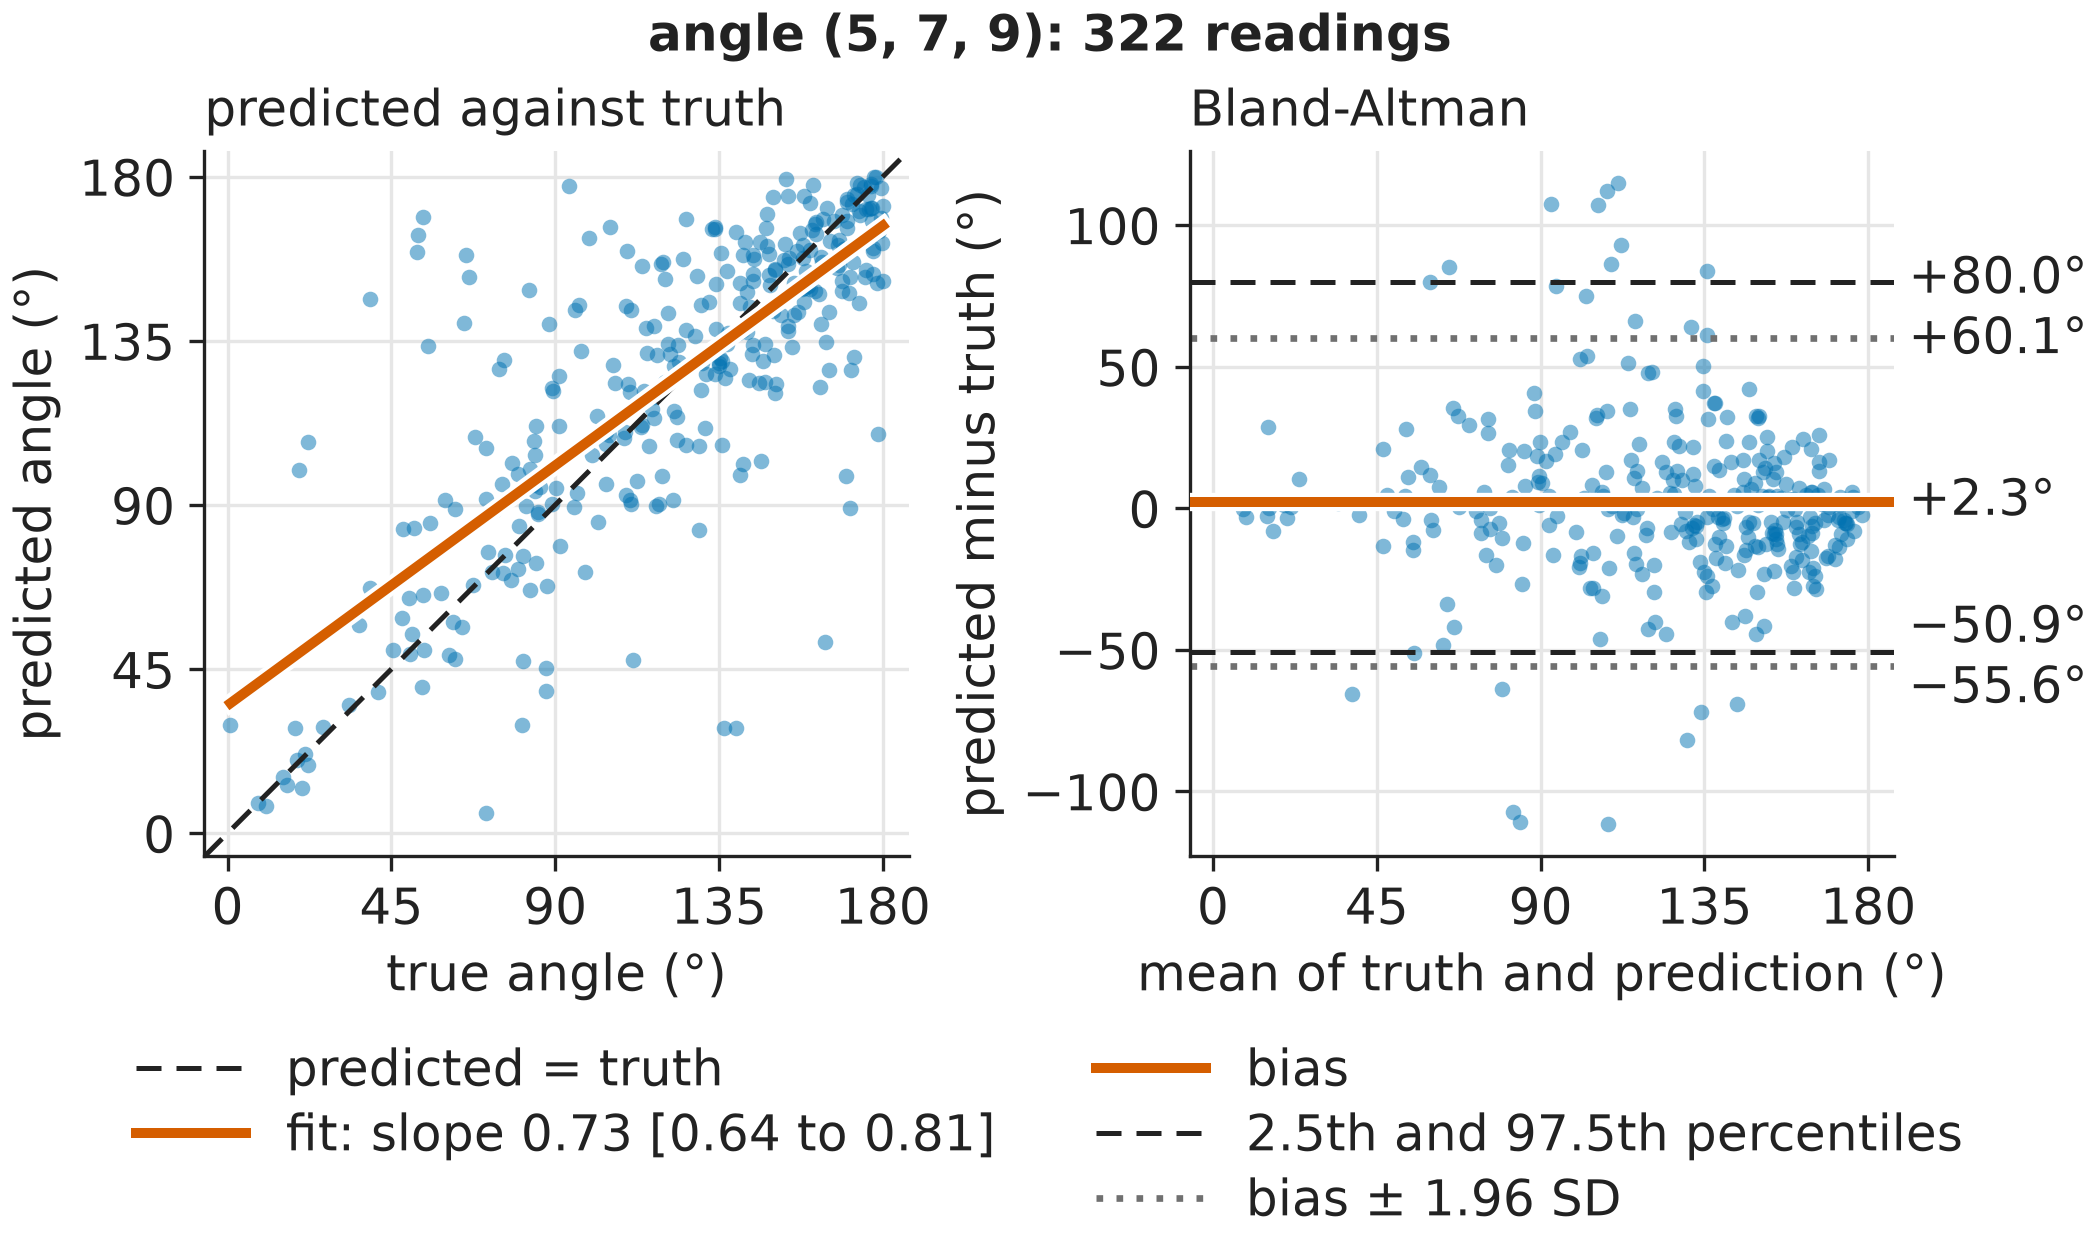

In [4]:
truth = pa.load_coco("gt_200.json")
predicted = pa.load_coco_results("pred_yolo11n.json", "gt_200.json", min_confidence=0.5)

result = pa.audit(
    pa.pair(truth, predicted), pa.angle(5, 7, 9), big_error=15, size_bands=[30, 60]
)

print(f"read {result.n} of {result.measurable} measurable instances")
print(
    f"mean |error|  {result.mean_abs_error:.2f} deg, 95% CI {result.mean_abs_error_ci[0]:.2f} to {result.mean_abs_error_ci[1]:.2f}"
)
print(f"bias          {result.bias:+.2f} deg")
print(f">= 15 deg     {result.big_error_rate:.1%}")
print(
    f"slope         {result.slope:.3f} (jitter alone: {result.jitter_gain:.3f}, gap {result.gain_gap:+.3f})"
)
print("not read     ", result.not_read)
print()
for b in result.size_bands:
    edge = f"{b.low:.0f}+" if b.high == float("inf") else f"{b.low:.0f} to {b.high:.0f}"
    print(
        f"arm {edge} px: n {b.n}, mean |error| {b.mean_abs_error:.2f} deg, >= 15 deg {b.big_error_rate:.0%}"
    )
print()
print("largest errors:")
for r in result.worst(3):
    print(
        f"  {r.image}: truth {r.truth:.1f}, predicted {r.predicted:.1f}, error {r.error:+.1f}"
    )

# Predicted against true angle, and a Bland-Altman plot (needs matplotlib)
from IPython.display import Image, display

result.plot("panels.png")
result.to_markdown("report.md")  # explains every line of the summary
result.to_csv("readings.csv")  # one row per reading
display(Image("panels.png"))

In [5]:
# a result on its own shows the summary the command line prints
result

angle (5, 7, 9): read 322 of 380 labelled instances
  not read     no matching prediction 35, prediction lacked a point 23, unmeasurable 0
  not counted  206 with a point unlabelled in the truth, 79 unmatched predictions
  bias         +2.27° [-1.21 to +6.15], median +0.52°
  limits       -50.90° to +79.99° (percentile, 2.5th to 97.5th; JSON percentile_limits)
  |error|      mean 19.48° [17.05 to 22.13], median 12.59°, 95th pct 68.99°
  RMSE         29.57° [25.30 to 33.94]
  >= 15°       43.2% [37.9% to 48.6%]
  by size      0-30 px 58% (n 134), 30-60 px 37% (n 112), 60+ px 26% (n 76)
  slope        0.731 [0.639 to 0.814] (pred on truth, 1 is ideal); Theil-Sen 0.786
  ICC(A,1)     0.762 [0.677 to 0.827]
  ! 2.5% of errors fall below the normal limits and 4.3% above them, against 2.5% each for a normal error: use the percentile limits.

## Reading the output

Each point below is covered in [docs/statistics.md](https://github.com/8rulerstar/poseaudit/blob/main/docs/statistics.md); `report.md` written above explains every line of the summary.

- **These are disagreements with one human label, not the model's error against the world.** COCO's own annotators disagree: by the rough estimate in [Reading the demo](https://github.com/8rulerstar/poseaudit/blob/main/docs/statistics.md#reading-the-demo), the label spread COCO publishes moves this elbow angle by 11 to 16 degrees on average, so a good part of the error may be the labels'. With a reference better than the model (motion capture, careful relabelling), the same figures describe the model.
- **not read / not counted.** Unlabelled points, unmatched people and missing predicted points are counted apart, so a model that skips hard cases does not look better for it.
- **by size.** Disagreement grows as arms get smaller. [What the demo shows](https://github.com/8rulerstar/poseaudit/blob/main/docs/statistics.md#what-the-demo-shows) calls this an association, not the whole cause.
- **bias and limits.** The small signed bias hides the size effect. The printed limits are the 2.5th to 97.5th percentiles of the errors; a `!` line says when the normal limits would be misleading.
- **slope vs jitter.** The slope is that of predicted on true angle (`gain` in the JSON). Keypoint jitter alone pulls it below 1, so it is compared with a jitter reference. A gap means the model reads angle differences as smaller than its own scatter explains, but swaps, gross failures and noisy labels can also cause it: with noisy labels, read the size of the gap, not the p. See [Does the model squash large angles?](https://github.com/8rulerstar/poseaudit/blob/main/docs/statistics.md#does-the-model-squash-large-angles)
- **Sorting trap.** Bias in bands sorted by the truth leans toward squashing when the labels are noisy. See [Which way you sort decides the story](https://github.com/8rulerstar/poseaudit/blob/main/docs/statistics.md#which-way-you-sort-decides-the-story) and [Limitations](https://github.com/8rulerstar/poseaudit/blob/main/docs/statistics.md#limitations).

## 3. Your own data

Upload your files with the folder icon on the left, then set the paths below. The cells skip themselves until the files exist.

**COCO format**: a keypoint annotation file and a results file. `--min-conf` sets which predicted points count as seen (without it every returned point counts, and a warning says so).

In [6]:
import os

GT_JSON = "annotations.json"  # COCO keypoint annotations
PRED_JSON = "results.json"  # COCO results format

if os.path.exists(GT_JSON) and os.path.exists(PRED_JSON):
    !poseaudit audit --format coco --gt {GT_JSON} --pred {PRED_JSON} \
        --min-conf 0.5 --angle 5,7,9 --big-error 15 \
        --report report_mine.md --plot panels_mine.png --csv readings_mine.csv
else:
    print("Upload", GT_JSON, "and", PRED_JSON, "to run this cell.")

Upload annotations.json and results.json to run this cell.


**YOLO format**: folders of Ultralytics pose `.txt` files, one per image. YOLO coordinates are fractions of width and height, so give the image size (`--image-size W H`, width first) or an image folder (`--images DIR`, safer), and the number of keypoints per instance.

Other measures: `--tilt I,J` (axis from vertical), `--length I,J` (pixels), `--ratio I,J,K,L`. Run `!poseaudit audit --help` for every option; for frames of one video or photos of one subject, add `--cluster REGEX` so the intervals are not too narrow.

In [7]:
LABELS = "labels"  # YOLO pose labels (ground truth)
PREDS = "predictions"  # YOLO pose predictions, with point confidences

if os.path.isdir(LABELS) and os.path.isdir(PREDS):
    !poseaudit audit --format yolo --gt {LABELS} --pred {PREDS} \
        --image-size 640 480 --keypoints 17 --min-conf 0.5 \
        --angle 5,7,9 --big-error 15
else:
    print("Upload the", LABELS, "and", PREDS, "folders to run this cell.")

Upload the labels and predictions folders to run this cell.
